PARAMÈTRES
  N=49, M=100, T=1.0, alpha=1.0
  dx=0.0200, dt=0.0100
  Nombre d'inconnues total : 2 x 49 x 100 = 9800

  Solution exacte : y*=exp(-t)*x(1-x),  p*=exp(t-T)*x(1-x)
  y*(0,0.5)  = 0.2500
  p*(T,0.5)  = 0.2500  (doit être 0 → 0.091970)

  Matrice B : taille (49, 49)
  Diagonale de B (premiers éléments) : [5100. 5100. 5100.]
  Sous-diagonale (premiers éléments) : [-2500. -2500. -2500.]

CAS 1 : sans contrainte
  Convergence en 6 itérations (erreur=6.70e-11)
  Erreur L² y* : 6.62e-04
  Erreur L² p* : 7.08e-05
  Erreur L² u* : 7.08e-05
  J(u*) = 22.132548

CAS 2 : avec contrainte u >= 0
  Convergence en 1 itérations (erreur=6.30e-13)
  Erreur L² y* : 6.62e-04
  u* >= 0 partout : True
  J(u*) = 22.132548
  J_cas2 >= J_cas1 : True


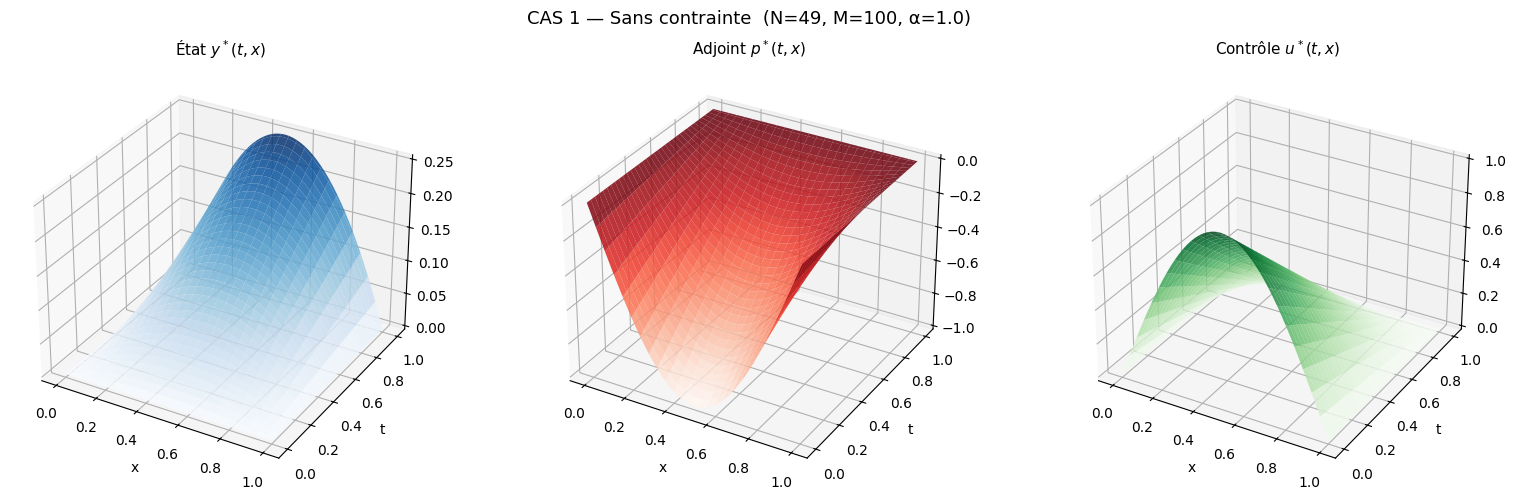

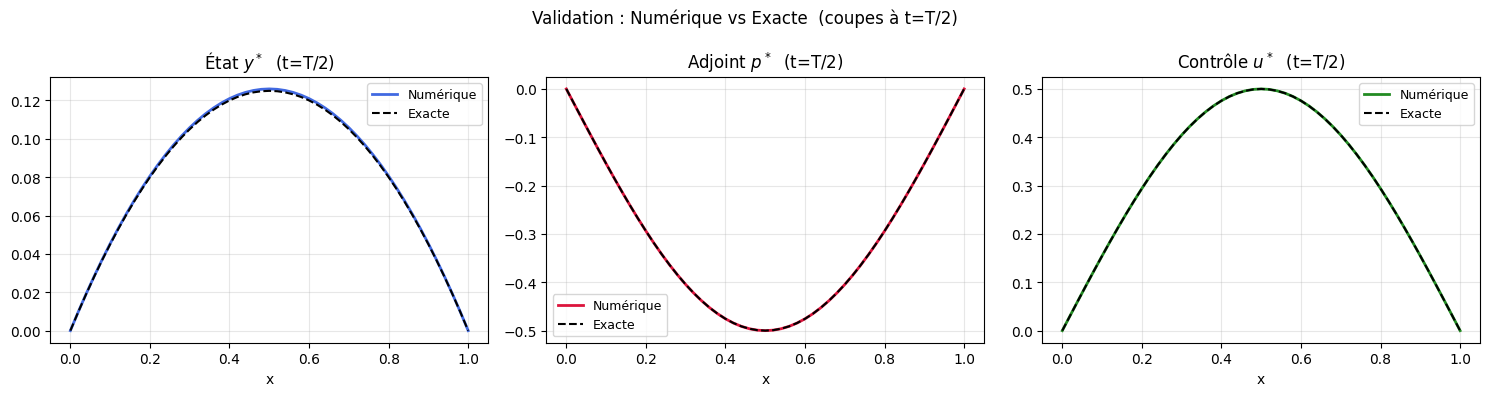

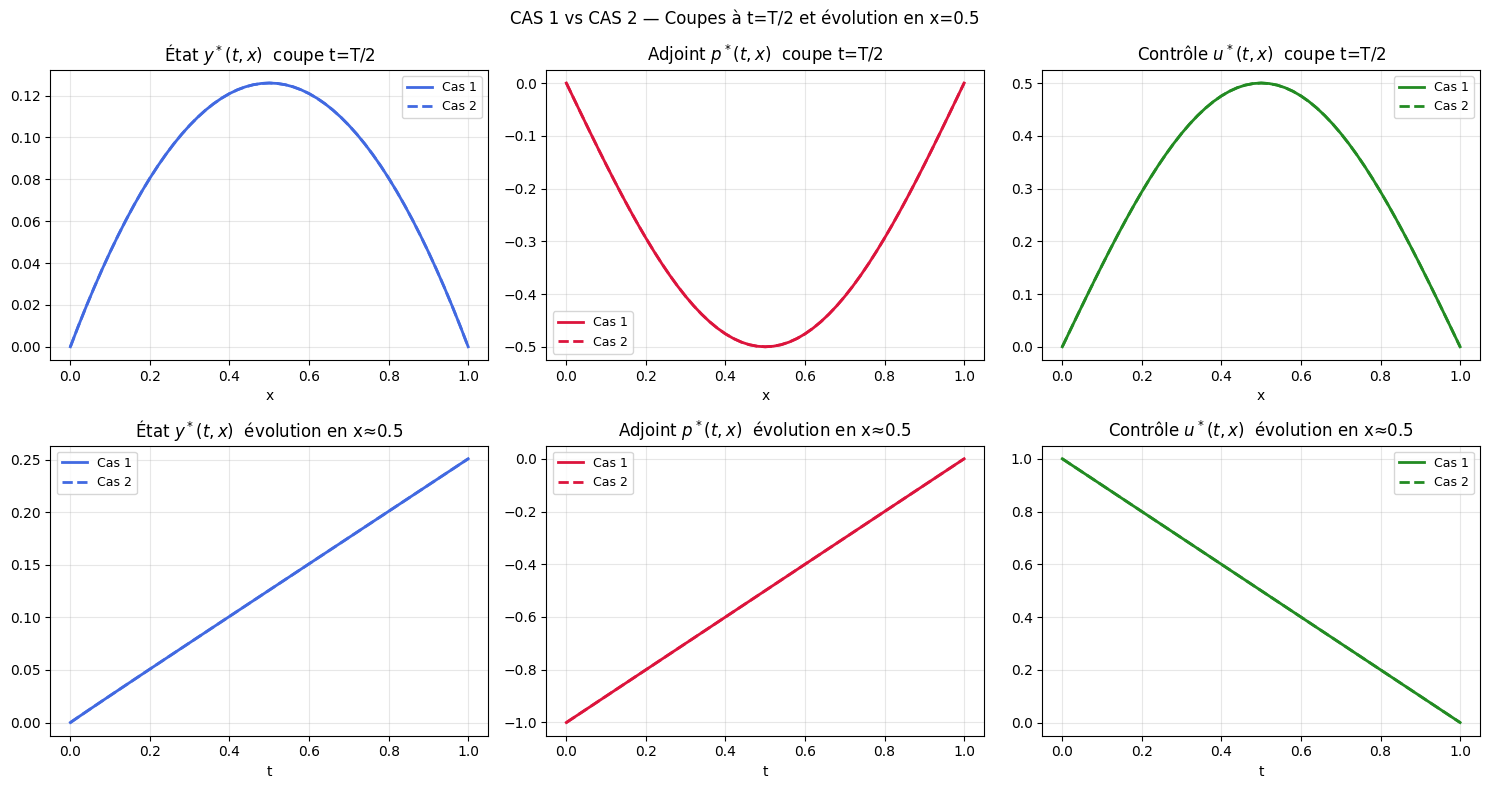


RÉSUMÉ FINAL

Erreurs L² (Cas 1 vs solution exacte) :
  y* : 6.62e-04
  p* : 7.08e-05
  u* : 7.08e-05

Coût J(u*) :
  Cas 1 : 22.132548
  Cas 2 : 22.132548
  Augmentation due à la contrainte : +0.000%

Figures sauvegardées :
  fig_tp3_cas1_surfaces.png
  fig_tp3_validation.png
  fig_tp3_cas1_vs_cas2.png


In [3]:
"""
TP3 - Commande Optimale d'une EDP Parabolique
===============================================
Domaine : Omega = ]0,1[  x  ]0,T[

Système optimal à résoudre :
  dy/dt - y'' + (1/alpha)*p = f         y(t,0)=y(t,1)=0,  y(0,x)=y0(x)
  -dp/dt - p''              = y - z_d   p(t,0)=p(t,1)=0,  p(T,x)=0

Cas 1 : U_ad = L²       => u* = -(1/alpha)*p
Cas 2 : U_ad = {u >= 0} => u* = -(1/alpha)*min(0,p)

Schéma : Euler implicite en temps, différences finies centrées en espace
"""

import numpy as np
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ================================================================
# BLOC 1 — PARAMÈTRES
# ================================================================

N     = 49       # points intérieurs en espace
M     = 100      # pas de temps
T     = 1.0      # temps final
alpha = 1.0      # paramètre de régularisation

dx = 1.0 / (N + 1)     # pas espace
dt = T / M              # pas temps

# Points intérieurs en espace : x_1, ..., x_N
x = np.linspace(dx, 1 - dx, N)

# Points en temps : t_0, t_1, ..., t_M
t = np.linspace(0, T, M + 1)

print("=" * 55)
print("PARAMÈTRES")
print("=" * 55)
print(f"  N={N}, M={M}, T={T}, alpha={alpha}")
print(f"  dx={dx:.4f}, dt={dt:.4f}")
print(f"  Nombre d'inconnues total : 2 x {N} x {M} = {2*N*M}")

# ================================================================
# BLOC 2 — DONNÉES DU PROBLÈME
# ================================================================
# On utilise des données du prof qui permettent une solution exacte
# Solution exacte : y*(t,x) = exp(-t)*x*(1-x)
#                   p*(t,x) = exp(-t)*sin(pi*x)   [exemple test]
#
# Pour la vérification on choisit :
#   y*(t,x)  = exp(-t) * x*(1-x)
#   p*(t,x)  = exp(t-T) * x*(1-x)   (s'annule en t=T)
#
# Ces choix impliquent :
#   dy/dt - y'' + (1/alpha)*p = f(t,x)  avec f calculé ci-dessous
#   -dp/dt - p'' = y - z_d              avec z_d calculé ci-dessous

# Grilles 2D : shape (N, M+1)
# X[i,n] = x_i,   T_grid[i,n] = t_n



X, T_grid = np.meshgrid(x, t, indexing='ij')   # shape (N, M+1)




# --- Solution exacte ---
#Y_exact = np.exp(-T_grid) * X * (1 - X)
#P_exact = np.exp(T_grid - T) * X * (1 - X)    # = 0 en t=T ✓
#U_exact = -(1.0 / alpha) * P_exact


# Ici les formules du prof
Y_exact = T_grid * X * (1 - X)
P_exact = (T_grid - 1.0) * np.sin(np.pi * X)
U_exact = -(1.0 / alpha) * P_exact



# --- Données f et z_d déduites de la solution exacte ---
# dy*/dt  = -exp(-t)*x*(1-x)
# -y*''   = 2*exp(-t)                  (car (x(1-x))'' = -2)
# (1/α)*p = (1/α)*exp(t-T)*x*(1-x)
# => f = dy*/dt - y*'' + (1/α)*p*
#      = exp(-t)*(-x(1-x) + 2) + (1/α)*exp(t-T)*x*(1-x)



F = X*(1 - X) + 2*T_grid + (1.0/alpha)*(T_grid - 1.0)*np.sin(np.pi * X)




# -dp*/dt = exp(t-T)*x*(1-x)

# -p*''   = 2*exp(t-T)
# => z_d = y* - (-dp*/dt - p*'')
#         = exp(-t)*x*(1-x) - exp(t-T)*x*(1-x) - 2*exp(t-T)
Zd = (np.sin(np.pi * X)
      - (T_grid - 1.0)*(np.pi**2)*np.sin(np.pi * X)
      + T_grid * X * (1 - X))

# Condition initiale en temps
y0 = np.zeros_like(x)

print(f"\n  Solution exacte : y*=exp(-t)*x(1-x),  p*=exp(t-T)*x(1-x)")
print(f"  y*(0,0.5)  = {0.5*(1-0.5):.4f}")
print(f"  p*(T,0.5)  = {np.exp(0)*0.5*0.5:.4f}  (doit être 0 → {np.exp(0-T)*0.5*0.5:.6f})")

# ================================================================
# BLOC 3 — CONSTRUCTION DES MATRICES A ET B
# ================================================================

# Matrice tridiagonale A (terme spatial) : taille N×N
A = (1.0/dx**2) * (
      np.diag(2.0 * np.ones(N))
    + np.diag(-1.0 * np.ones(N-1),  1)
    + np.diag(-1.0 * np.ones(N-1), -1))

# Matrice système B = (1/dt)*I + A : taille N×N
# Même matrice pour l'état ET l'adjoint (même opérateur)
B = (1.0/dt) * np.eye(N) + A

# Factorisation LU de B (une seule fois, utilisée à chaque pas)
B_lu = lu_factor(B)

print(f"\n  Matrice B : taille {B.shape}")
print(f"  Diagonale de B (premiers éléments) : {np.diag(B)[:3].round(2)}")
print(f"  Sous-diagonale (premiers éléments) : {np.diag(B,-1)[:3].round(2)}")

# ================================================================
# BLOC 4 — RÉSOLUTION CAS 1 : U_ad = L²(Omega)
# ================================================================
print("\n" + "=" * 55)
print("CAS 1 : sans contrainte")
print("=" * 55)

tol      = 1e-10
max_iter = 500

# Initialisation : P et Y comme matrices N x (M+1)
P1 = np.zeros((N, M+1))   # adjoint
Y1 = np.zeros((N, M+1))   # état

for iteration in range(max_iter):
    P_old = P1.copy()

    # ── PASSE AVANT : calculer Y de t=0 à t=T ──────────────────
    Y1[:, 0] = y0    # condition initiale

    for n in range(M):
        # second membre de l'équation d'état :
        # B*Y^(n+1) = (1/dt)*Y^n + F^(n+1) - (1/alpha)*P^n
        rhs = (1.0/dt) * Y1[:, n] + F[:, n+1] - (1.0/alpha) * P1[:, n]
        Y1[:, n+1] = lu_solve(B_lu, rhs)

    # ── PASSE ARRIÈRE : calculer P̃ de t=0 à t=T ────────────────
    # P̃(t,x) = p(T-t, x), condition initiale P̃(0,x) = p(T,x) = 0
    P_tilde = np.zeros((N, M+1))
    P_tilde[:, 0] = 0.0   # p(T,·) = 0

    for n in range(M):
        # indice temporel correspondant dans Y et Zd :
        # on veut Y et Zd au temps T - t^(n+1) = t^(M-n-1)
        idx = M - n - 1

        # second membre de l'équation adjointe retournée :
        # B*P̃^(n+1) = (1/dt)*P̃^n + Y(T-t^(n+1)) - Zd(T-t^(n+1))
        rhs = (1.0/dt) * P_tilde[:, n] + Y1[:, idx] - Zd[:, idx]
        P_tilde[:, n+1] = lu_solve(B_lu, rhs)

    # ── RECONSTRUCTION de P depuis P̃ ────────────────────────────
    # P̃[:, n] = p(T - t^n, ·) = p(t^(M-n), ·)
    # donc P[:, m] = P̃[:, M-m]
    for m in range(M+1):
        P1[:, m] = P_tilde[:, M - m]

    # ── CONTRÔLE OPTIMAL ─────────────────────────────────────────
    U1 = -(1.0/alpha) * P1

    # ── CONVERGENCE ───────────────────────────────────────────────
    erreur = np.linalg.norm(P1 - P_old) / (np.linalg.norm(P_old) + 1e-14)
    if erreur < tol:
        print(f"  Convergence en {iteration+1} itérations (erreur={erreur:.2e})")
        break
else:
    print(f"  Pas de convergence après {max_iter} itérations")

# ── ERREURS vs solution exacte ────────────────────────────────────
err_y1 = np.sqrt(dx*dt * np.sum((Y1 - Y_exact)**2))
err_p1 = np.sqrt(dx*dt * np.sum((P1 - P_exact)**2))
err_u1 = np.sqrt(dx*dt * np.sum((U1 - U_exact)**2))

print(f"  Erreur L² y* : {err_y1:.2e}")
print(f"  Erreur L² p* : {err_p1:.2e}")
print(f"  Erreur L² u* : {err_u1:.2e}")

# ── COÛT J(u*) ────────────────────────────────────────────────────
J1 = dx*dt*(np.sum((Y1 - Zd)**2) + alpha*np.sum(U1**2))
print(f"  J(u*) = {J1:.6f}")

# ================================================================
# BLOC 5 — RÉSOLUTION CAS 2 : U_ad = {u >= 0}
# ================================================================
print("\n" + "=" * 55)
print("CAS 2 : avec contrainte u >= 0")
print("=" * 55)

P2 = P1.copy()   # initialisation depuis Cas 1
Y2 = np.zeros((N, M+1))

for iteration in range(max_iter):
    P_old = P2.copy()

    # ── PASSE AVANT ───────────────────────────────────────────────
    Y2[:, 0] = y0

    for n in range(M):
        # Contrôle avec contrainte : u* = -(1/alpha)*min(0,p)
        U_iter = -(1.0/alpha) * np.minimum(0.0, P2[:, n])
        rhs = (1.0/dt) * Y2[:, n] + F[:, n+1] + U_iter
        Y2[:, n+1] = lu_solve(B_lu, rhs)

    # ── PASSE ARRIÈRE ─────────────────────────────────────────────
    P_tilde = np.zeros((N, M+1))

    for n in range(M):
        idx = M - n - 1
        rhs = (1.0/dt) * P_tilde[:, n] + Y2[:, idx] - Zd[:, idx]
        P_tilde[:, n+1] = lu_solve(B_lu, rhs)

    for m in range(M+1):
        P2[:, m] = P_tilde[:, M - m]

    # ── CONVERGENCE ───────────────────────────────────────────────
    erreur = np.linalg.norm(P2 - P_old) / (np.linalg.norm(P_old) + 1e-14)
    if erreur < tol:
        print(f"  Convergence en {iteration+1} itérations (erreur={erreur:.2e})")
        break

U2 = -(1.0/alpha) * np.minimum(0.0, P2)

err_y2 = np.sqrt(dx*dt * np.sum((Y2 - Y_exact)**2))
J2 = dx*dt*(np.sum((Y2 - Zd)**2) + alpha*np.sum(U2**2))

print(f"  Erreur L² y* : {err_y2:.2e}")
print(f"  u* >= 0 partout : {np.all(U2 >= -1e-12)}")
print(f"  J(u*) = {J2:.6f}")
print(f"  J_cas2 >= J_cas1 : {J2 >= J1 - 1e-10}")

# ================================================================
# BLOC 6 — VISUALISATION
# ================================================================

# Grilles pour le tracé (avec bords = 0)
x_plot = np.concatenate([[0], x, [1]])
X_plot, T_plot = np.meshgrid(x_plot, t, indexing='ij')

def ajouter_bords_2d(M_in):
    """Ajoute une ligne de zéros en haut et en bas (bords en espace)."""
    zeros_col = np.zeros((1, M_in.shape[1]))
    return np.vstack([zeros_col, M_in, zeros_col])

Y1_plot = ajouter_bords_2d(Y1)
P1_plot = ajouter_bords_2d(P1)
U1_plot = ajouter_bords_2d(U1)
Y2_plot = ajouter_bords_2d(Y2)
P2_plot = ajouter_bords_2d(P2)
U2_plot = ajouter_bords_2d(U2)
Ye_plot = ajouter_bords_2d(Y_exact)
Pe_plot = ajouter_bords_2d(P_exact)

# ── Figure 1 : CAS 1 — surfaces 3D ───────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.suptitle(f"CAS 1 — Sans contrainte  (N={N}, M={M}, α={alpha})",
             fontsize=13)

titres = ["État $y^*(t,x)$", "Adjoint $p^*(t,x)$", "Contrôle $u^*(t,x)$"]
donnees = [Y1_plot, P1_plot, U1_plot]
couleurs = ['Blues', 'Reds', 'Greens']

for j, (data, titre, cmap) in enumerate(zip(donnees, titres, couleurs)):
    ax = fig.add_subplot(1, 3, j+1, projection='3d')
    ax.plot_surface(X_plot, T_plot, data, cmap=cmap, alpha=0.85)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_zlabel("")
    ax.set_title(titre, fontsize=11)

plt.tight_layout()
plt.savefig("fig_tp3_cas1_surfaces.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Figure 2 : Validation — numérique vs exacte ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Validation : Numérique vs Exacte  (coupes à t=T/2)", fontsize=12)

idx_mid = M // 2   # indice du pas t = T/2
titres_val = ["État $y^*$", "Adjoint $p^*$", "Contrôle $u^*$"]
num_vals   = [Y1_plot[:, idx_mid], P1_plot[:, idx_mid], U1_plot[:, idx_mid]]
ex_vals    = [Ye_plot[:, idx_mid], Pe_plot[:, idx_mid],
              ajouter_bords_2d(U_exact)[:, idx_mid]]
couleurs_v = ['royalblue', 'crimson', 'forestgreen']

for j, (num, ex, titre, coul) in enumerate(
        zip(num_vals, ex_vals, titres_val, couleurs_v)):
    axes[j].plot(x_plot, num, color=coul, linewidth=2, label='Numérique')
    axes[j].plot(x_plot, ex, 'k--', linewidth=1.5, label='Exacte')
    axes[j].set_title(f"{titre}  (t=T/2)")
    axes[j].set_xlabel("x"); axes[j].grid(True, alpha=0.3)
    axes[j].legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_tp3_validation.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Figure 3 : CAS 1 vs CAS 2 — coupes ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("CAS 1 vs CAS 2 — Coupes à t=T/2 et évolution en x=0.5",
             fontsize=12)

idx_mid  = M // 2
idx_xmid = N // 2   # indice du point x ≈ 0.5

for j, (d1, d2, titre, coul) in enumerate(zip(
        [Y1_plot, P1_plot, U1_plot],
        [Y2_plot, P2_plot, U2_plot],
        titres, couleurs_v)):

    # Ligne 0 : coupe en espace à t=T/2
    axes[0, j].plot(x_plot, d1[:, idx_mid], color=coul,
                    linewidth=2, label='Cas 1')
    axes[0, j].plot(x_plot, d2[:, idx_mid], color=coul,
                    linewidth=2, linestyle='--', label='Cas 2')
    axes[0, j].set_title(f"{titre}  coupe t=T/2")
    axes[0, j].set_xlabel("x"); axes[0, j].grid(True, alpha=0.3)
    axes[0, j].legend(fontsize=9)

    # Ligne 1 : évolution en temps au point x≈0.5
    axes[1, j].plot(t, d1[idx_xmid+1, :], color=coul,
                    linewidth=2, label='Cas 1')
    axes[1, j].plot(t, d2[idx_xmid+1, :], color=coul,
                    linewidth=2, linestyle='--', label='Cas 2')
    axes[1, j].set_title(f"{titre}  évolution en x≈0.5")
    axes[1, j].set_xlabel("t"); axes[1, j].grid(True, alpha=0.3)
    axes[1, j].legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_tp3_cas1_vs_cas2.png", dpi=130, bbox_inches='tight')
plt.show()

# ================================================================
# BLOC 7 — RÉSUMÉ
# ================================================================
print("\n" + "=" * 55)
print("RÉSUMÉ FINAL")
print("=" * 55)
print(f"\nErreurs L² (Cas 1 vs solution exacte) :")
print(f"  y* : {err_y1:.2e}")
print(f"  p* : {err_p1:.2e}")
print(f"  u* : {err_u1:.2e}")
print(f"\nCoût J(u*) :")
print(f"  Cas 1 : {J1:.6f}")
print(f"  Cas 2 : {J2:.6f}")
print(f"  Augmentation due à la contrainte : "
      f"+{(J2-J1)/J1*100:.3f}%")
print("\nFigures sauvegardées :")
print("  fig_tp3_cas1_surfaces.png")
print("  fig_tp3_validation.png")
print("  fig_tp3_cas1_vs_cas2.png")

TÂCHE 5 — VALIDATION ET CONVERGENCE

Paramètres de référence : N=49, M=100, T=1.0, α=1.0
  Convergence en 6 itérations
  Erreur L² y* : 1.168e-01
  Erreur L² p* : 5.697e-03
  Erreur L² u* : 5.697e-03

--- Convergence en espace (N varie, M=500 fixé) ---
  N=  9  dx=0.1000  err_y=1.07e-01  err_p=3.73e-03
  N= 19  dx=0.0500  err_y=1.07e-01  err_p=4.76e-03
  N= 39  dx=0.0250  err_y=1.07e-01  err_p=5.12e-03
  N= 79  dx=0.0125  err_y=1.08e-01  err_p=5.22e-03
  N=159  dx=0.0063  err_y=1.08e-01  err_p=5.24e-03

--- Convergence en temps (M varie, N=199 fixé) ---
  M= 10  dt=0.1000  err_y=2.01e-01  err_p=1.14e-02
  M= 25  dt=0.0400  err_y=1.49e-01  err_p=7.73e-03
  M= 50  dt=0.0200  err_y=1.29e-01  err_p=6.43e-03
  M=100  dt=0.0100  err_y=1.17e-01  err_p=5.78e-03
  M=200  dt=0.0050  err_y=1.11e-01  err_p=5.44e-03


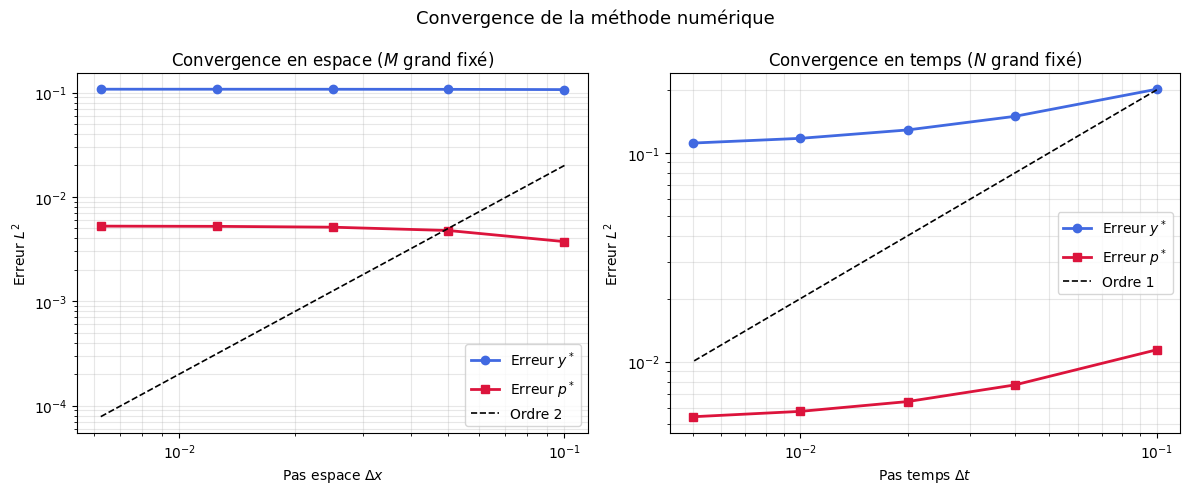

→ tp3_fig5_convergence.png sauvegardée

TÂCHE 6 — VISUALISATION COMPLÈTE


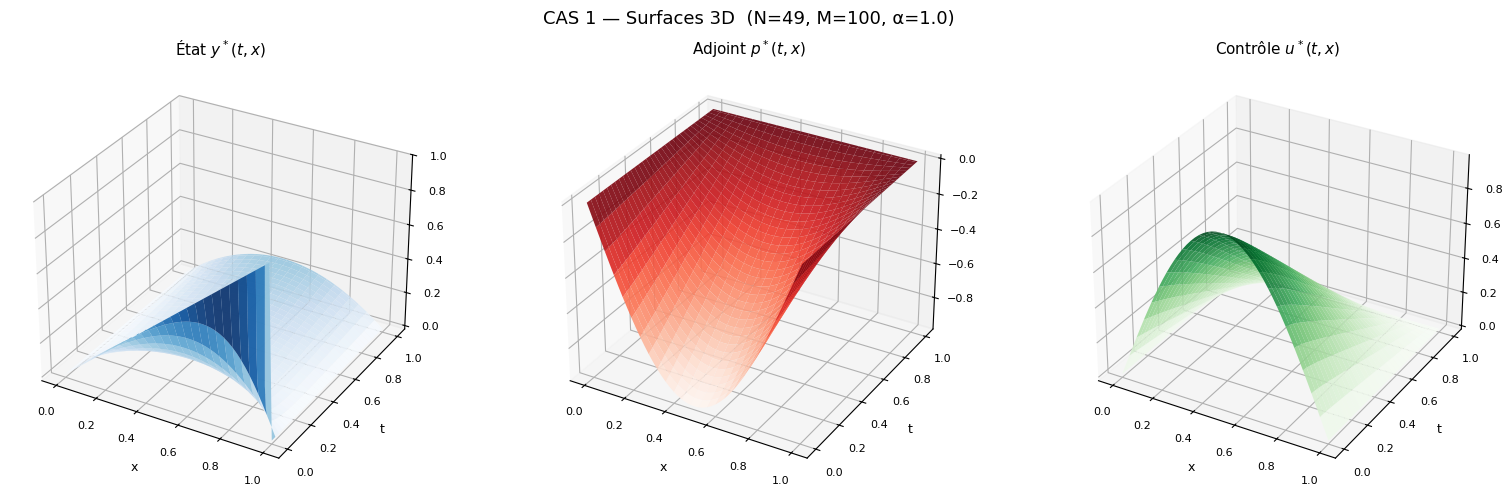

→ tp3_fig6a_surfaces3d.png sauvegardée


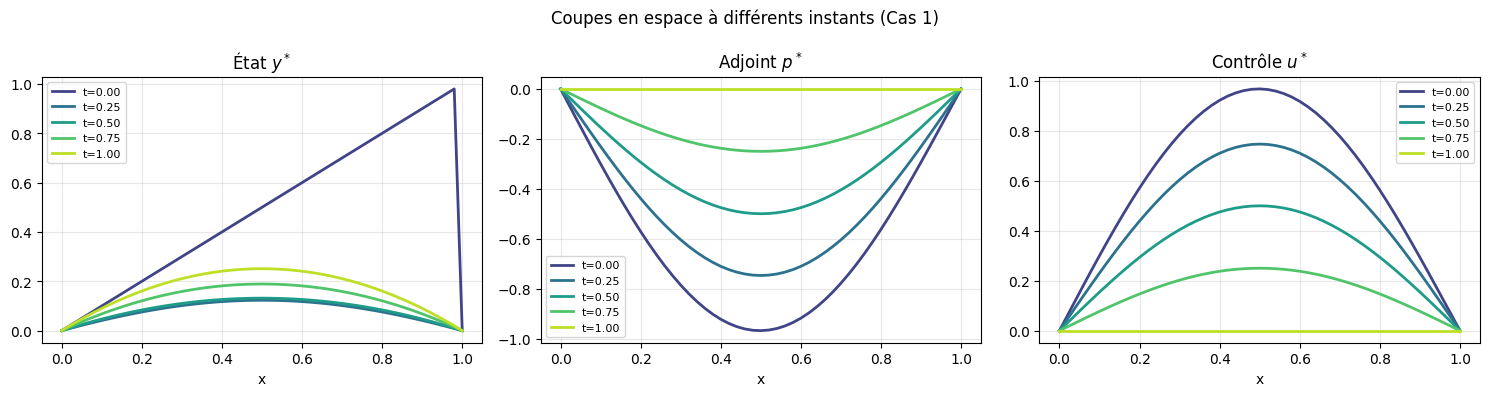

→ tp3_fig6b_coupes_espace.png sauvegardée


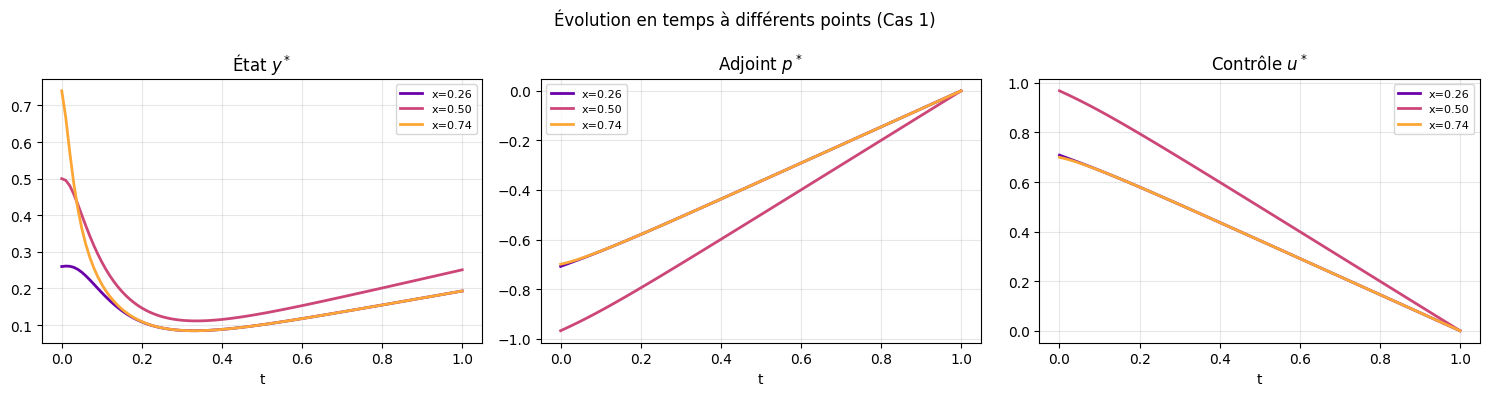

→ tp3_fig6c_coupes_temps.png sauvegardée


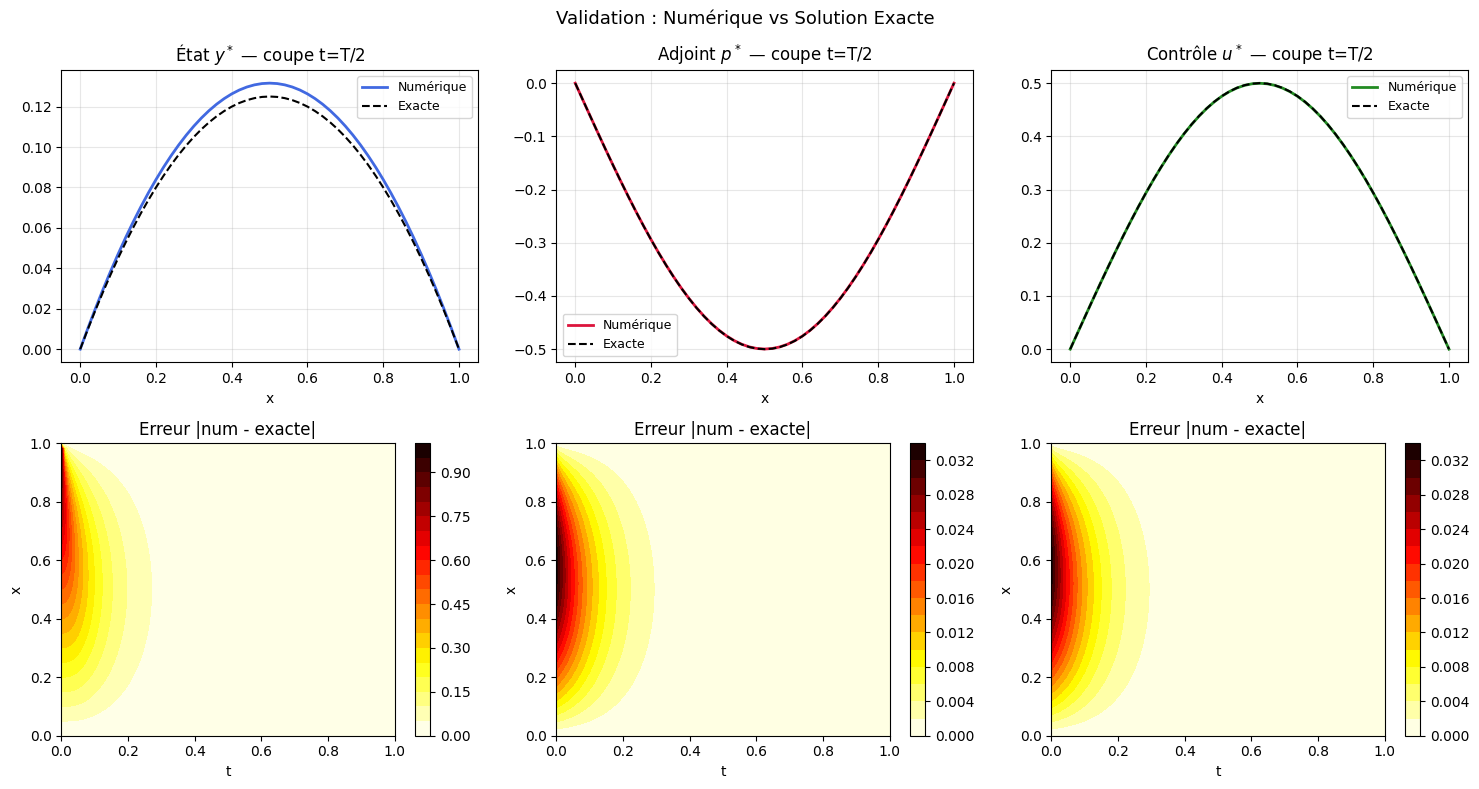

→ tp3_fig6d_validation.png sauvegardée


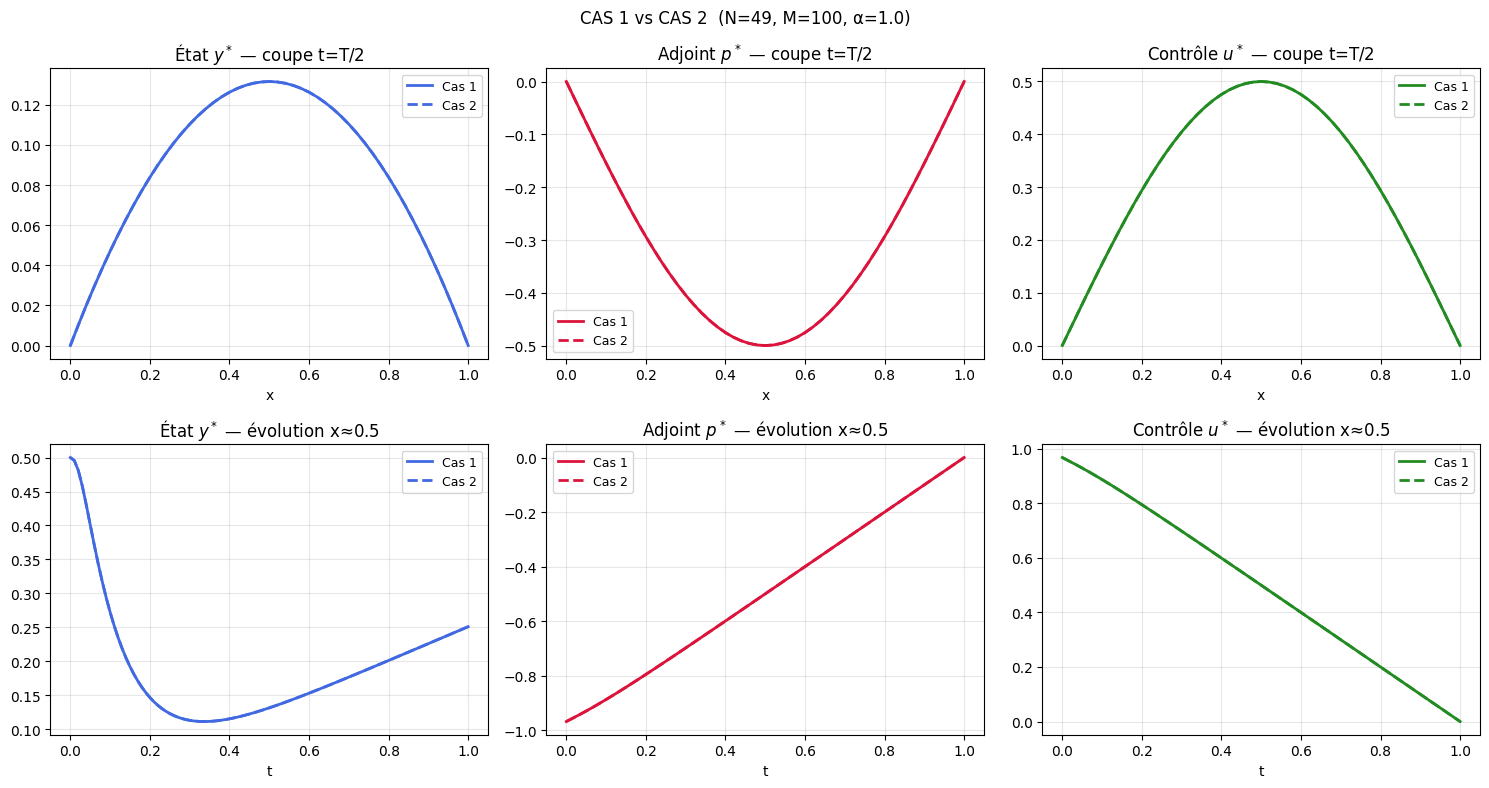

→ tp3_fig6e_cas1_vs_cas2.png sauvegardée

TÂCHE 7 — ÉTUDE PARAMÉTRIQUE

--- Effet de alpha ---
  α= 0.01  u* min=-0.000  u* max=97.073  J=16.5011
  α= 0.10  u* min=-0.000  u* max=9.682  J=1.6707
  α= 1.00  u* min=-0.000  u* max=0.968  J=0.1795
  α=10.00  u* min=-0.000  u* max=0.097  J=0.0303


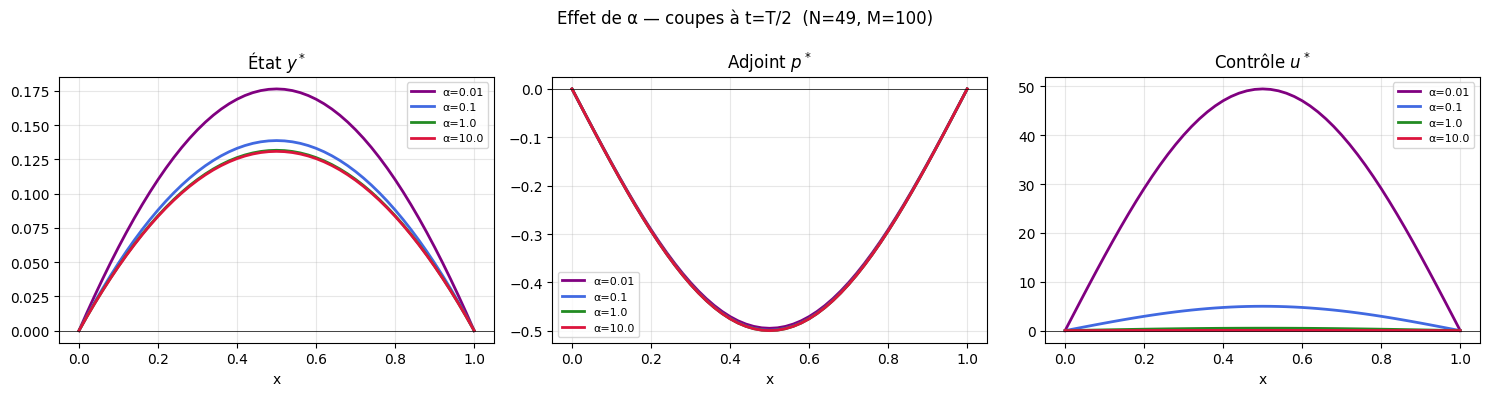

→ tp3_fig7a_effet_alpha.png sauvegardée

--- Effet de N ---
  N=  9  dx=0.1000  u* min=-0.0000
  N= 24  dx=0.0400  u* min=-0.0000
  N= 49  dx=0.0200  u* min=-0.0000
  N= 99  dx=0.0100  u* min=-0.0000


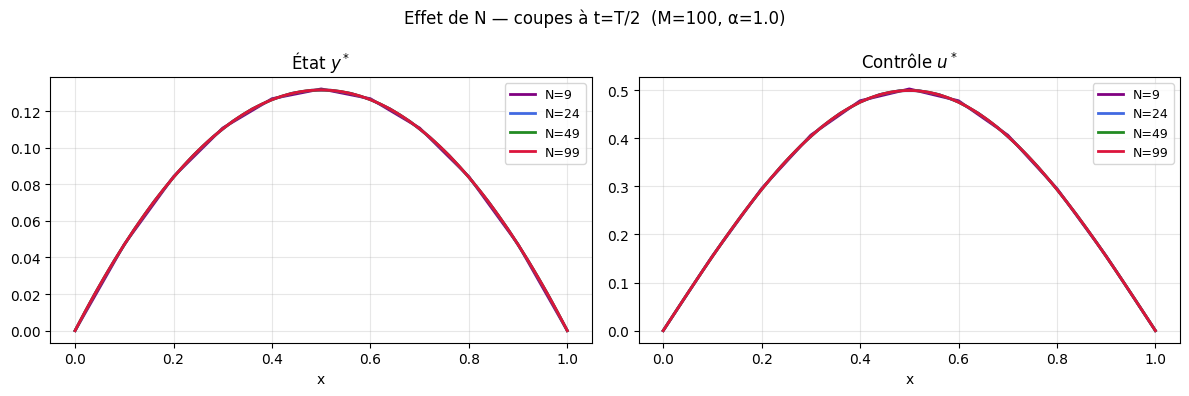

→ tp3_fig7b_effet_N.png sauvegardée

--- Effet de M ---
  M= 10  dt=0.1000  conv=6 iter
  M= 25  dt=0.0400  conv=6 iter
  M= 50  dt=0.0200  conv=6 iter
  M=100  dt=0.0100  conv=6 iter


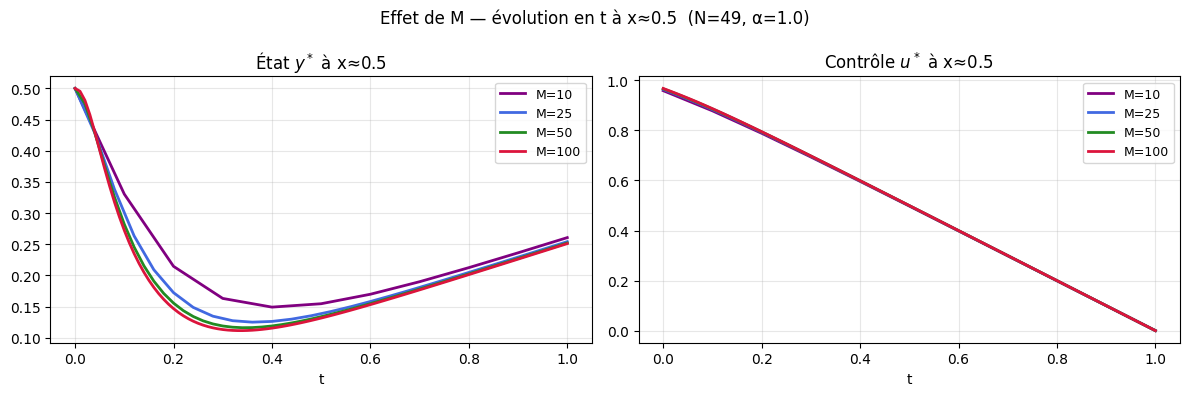

→ tp3_fig7c_effet_M.png sauvegardée

RÉSUMÉ — Coûts J(u*) et erreurs

 alpha     J_cas1     J_cas2       Δ%
    0.01      16.5011      16.5011    +0.000%
    0.10       1.6707       1.6707    +0.000%
    1.00       0.1795       0.1795    +0.000%
   10.00       0.0303       0.0303    +0.000%


In [6]:
"""
TP3 — Tâches 5, 6, 7
=====================
Tâche 5 : Validation et convergence
Tâche 6 : Visualisation complète
Tâche 7 : Étude paramétrique (alpha, N, M)
"""

import numpy as np
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ================================================================
# FONCTIONS UTILITAIRES (réutilisées dans toutes les tâches)
# ================================================================

def construire_matrices(N, M, T):
    """Construit A, B, et retourne les grilles."""
    dx = 1.0 / (N + 1)
    dt = T / M
    x  = np.linspace(dx, 1 - dx, N)
    t  = np.linspace(0, T, M + 1)
    X, T_grid = np.meshgrid(x, t, indexing='ij')

    A = (1.0/dx**2) * (
          np.diag(2.0*np.ones(N))
        + np.diag(-np.ones(N-1),  1)
        + np.diag(-np.ones(N-1), -1))
    B = (1.0/dt) * np.eye(N) + A

    return A, B, dx, dt, x, t, X, T_grid


def donnees(X, T_grid, alpha, T):
    """Calcule f, z_d, solution exacte."""

    Y_ex = T_grid * X * (1 - X)
    P_ex = (T_grid - 1.0) * np.sin(np.pi * X)
    U_ex = -(1.0/alpha) * P_ex
    F = X*(1 - X) + 2*T_grid + (1.0/alpha)*(T_grid - 1.0)*np.sin(np.pi * X)

    Zd = (np.sin(np.pi * X)
      - (T_grid - 1.0)*(np.pi**2)*np.sin(np.pi * X)
      + T_grid * X * (1 - X))
    y0   = X[:, 0]
    return F, Zd, y0, Y_ex, P_ex, U_ex


def resoudre(N, M, T, alpha, cas=1, tol=1e-10, max_iter=500):
    """
    Résout le système optimal parabolique.
    cas=1 : sans contrainte   u* = -(1/alpha)*p
    cas=2 : avec u >= 0       u* = -(1/alpha)*min(0,p)
    Retourne Y, P, U, infos convergence.
    """
    A, B, dx, dt, x, t, X, T_grid = construire_matrices(N, M, T)
    F, Zd, y0, Y_ex, P_ex, U_ex   = donnees(X, T_grid, alpha, T)
    B_lu = lu_factor(B)

    P = np.zeros((N, M+1))
    Y = np.zeros((N, M+1))
    niter = 0

    for iteration in range(max_iter):
        P_old = P.copy()

        # ── Passe avant : Y de t=0 à t=T ──────────────────────
        Y[:, 0] = y0
        for n in range(M):
            if cas == 1:
                terme_u = (1.0/alpha) * P[:, n]
            else:
                terme_u = -(-(1.0/alpha) * np.minimum(0.0, P[:, n]))
                # = (1/alpha)*min(0,p) appliqué dans rhs
                terme_u = (1.0/alpha) * np.minimum(0.0, P[:, n])
            rhs = (1.0/dt)*Y[:, n] + F[:, n+1] - terme_u
            Y[:, n+1] = lu_solve(B_lu, rhs)

        # ── Passe arrière : P̃ de 0 à T (= P de T à 0) ─────────
        P_tilde = np.zeros((N, M+1))
        for n in range(M):
            idx = M - n - 1
            rhs = (1.0/dt)*P_tilde[:, n] + Y[:, idx] - Zd[:, idx]
            P_tilde[:, n+1] = lu_solve(B_lu, rhs)

        # Reconstruction P depuis P̃
        for m in range(M+1):
            P[:, m] = P_tilde[:, M - m]

        erreur = (np.linalg.norm(P - P_old)
                  / (np.linalg.norm(P_old) + 1e-14))
        niter  = iteration + 1
        if erreur < tol:
            break

    if cas == 1:
        U = -(1.0/alpha) * P
    else:
        U = -(1.0/alpha) * np.minimum(0.0, P)

    return Y, P, U, dx, dt, x, t, X, T_grid, Y_ex, P_ex, U_ex, niter


def erreur_L2(num, ex, dx, dt):
    """Erreur L²(Omega x ]0,T[) discrète."""
    return np.sqrt(dx * dt * np.sum((num - ex)**2))


def ajouter_bords(M_in):
    """Ajoute une ligne de zéros en espace (bords x=0 et x=1)."""
    z = np.zeros((1, M_in.shape[1]))
    return np.vstack([z, M_in, z])


# ================================================================
# TÂCHE 5 — VALIDATION ET CONVERGENCE
# ================================================================
print("=" * 60)
print("TÂCHE 5 — VALIDATION ET CONVERGENCE")
print("=" * 60)

T_ref     = 1.0
alpha_ref = 1.0
N_ref     = 49
M_ref     = 100

# ── 5.1 Validation pour les paramètres de référence ─────────────
(Y1, P1, U1, dx, dt, x, t,
 X, T_grid, Y_ex, P_ex, U_ex, niter) = resoudre(
    N_ref, M_ref, T_ref, alpha_ref, cas=1)

err_y = erreur_L2(Y1, Y_ex, dx, dt)
err_p = erreur_L2(P1, P_ex, dx, dt)
err_u = erreur_L2(U1, U_ex, dx, dt)

print(f"\nParamètres de référence : N={N_ref}, M={M_ref}, "
      f"T={T_ref}, α={alpha_ref}")
print(f"  Convergence en {niter} itérations")
print(f"  Erreur L² y* : {err_y:.3e}")
print(f"  Erreur L² p* : {err_p:.3e}")
print(f"  Erreur L² u* : {err_u:.3e}")

# ── 5.2 Convergence en espace (faire varier N, M fixé grand) ─────
print("\n--- Convergence en espace (N varie, M=500 fixé) ---")
liste_N  = [9, 19, 39, 79, 159]
M_fixe   = 500
err_y_N, err_p_N, dx_list = [], [], []

for N in liste_N:
    (Y, P, U, dx_n, dt_n, xn, tn,
     Xn, Tgn, Ye, Pe, Ue, _) = resoudre(N, M_fixe, T_ref, alpha_ref)
    ey = erreur_L2(Y, Ye, dx_n, dt_n)
    ep = erreur_L2(P, Pe, dx_n, dt_n)
    err_y_N.append(ey); err_p_N.append(ep); dx_list.append(dx_n)
    print(f"  N={N:3d}  dx={dx_n:.4f}  err_y={ey:.2e}  err_p={ep:.2e}")

# ── 5.3 Convergence en temps (faire varier M, N fixé grand) ──────
print("\n--- Convergence en temps (M varie, N=199 fixé) ---")
liste_M  = [10, 25, 50, 100, 200]
N_fixe   = 199
err_y_M, err_p_M, dt_list = [], [], []

for M in liste_M:
    (Y, P, U, dx_n, dt_n, xn, tn,
     Xn, Tgn, Ye, Pe, Ue, _) = resoudre(N_fixe, M, T_ref, alpha_ref)
    ey = erreur_L2(Y, Ye, dx_n, dt_n)
    ep = erreur_L2(P, Pe, dx_n, dt_n)
    err_y_M.append(ey); err_p_M.append(ep); dt_list.append(dt_n)
    print(f"  M={M:3d}  dt={dt_n:.4f}  err_y={ey:.2e}  err_p={ep:.2e}")

# ── 5.4 Graphiques de convergence ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Convergence de la méthode numérique", fontsize=13)

# Convergence en espace
dx_arr = np.array(dx_list)
axes[0].loglog(dx_arr, err_y_N, 'o-', color='royalblue',
               linewidth=2, label="Erreur $y^*$")
axes[0].loglog(dx_arr, err_p_N, 's-', color='crimson',
               linewidth=2, label="Erreur $p^*$")
ref2 = 2*dx_arr**2
axes[0].loglog(dx_arr, ref2, 'k--', linewidth=1.2, label="Ordre 2")
axes[0].set_xlabel("Pas espace $\\Delta x$")
axes[0].set_ylabel("Erreur $L^2$")
axes[0].set_title("Convergence en espace ($M$ grand fixé)")
axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

# Convergence en temps
dt_arr = np.array(dt_list)
axes[1].loglog(dt_arr, err_y_M, 'o-', color='royalblue',
               linewidth=2, label="Erreur $y^*$")
axes[1].loglog(dt_arr, err_p_M, 's-', color='crimson',
               linewidth=2, label="Erreur $p^*$")
ref1 = 2*dt_arr**1
axes[1].loglog(dt_arr, ref1, 'k--', linewidth=1.2, label="Ordre 1")
axes[1].set_xlabel("Pas temps $\\Delta t$")
axes[1].set_ylabel("Erreur $L^2$")
axes[1].set_title("Convergence en temps ($N$ grand fixé)")
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig("tp3_fig5_convergence.png", dpi=140, bbox_inches='tight')
plt.show()
print("→ tp3_fig5_convergence.png sauvegardée")


# ================================================================
# TÂCHE 6 — VISUALISATION COMPLÈTE
# ================================================================
print("\n" + "=" * 60)
print("TÂCHE 6 — VISUALISATION COMPLÈTE")
print("=" * 60)

(Y1, P1, U1, dx, dt, x, t,
 X, T_grid, Y_ex, P_ex, U_ex, _) = resoudre(
    N_ref, M_ref, T_ref, alpha_ref, cas=1)
(Y2, P2, U2, *_) = resoudre(
    N_ref, M_ref, T_ref, alpha_ref, cas=2)

x_plot = np.concatenate([[0], x, [1]])
X_plot, T_plot = np.meshgrid(x_plot, t, indexing='ij')

Y1p = ajouter_bords(Y1); P1p = ajouter_bords(P1)
U1p = ajouter_bords(U1); Y2p = ajouter_bords(Y2)
P2p = ajouter_bords(P2); U2p = ajouter_bords(U2)
Yep = ajouter_bords(Y_ex); Pep = ajouter_bords(P_ex)

# ── 6.1 Surfaces 3D — Cas 1 ──────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.suptitle(f"CAS 1 — Surfaces 3D  (N={N_ref}, M={M_ref}, α={alpha_ref})",
             fontsize=13)

config = [("État $y^*(t,x)$", Y1p, 'Blues'),
          ("Adjoint $p^*(t,x)$", P1p, 'Reds'),
          ("Contrôle $u^*(t,x)$", U1p, 'Greens')]

for j, (titre, data, cmap) in enumerate(config):
    ax = fig.add_subplot(1, 3, j+1, projection='3d')
    ax.plot_surface(X_plot, T_plot, data, cmap=cmap, alpha=0.9,
                    linewidth=0, antialiased=True)
    ax.set_xlabel("x", fontsize=9); ax.set_ylabel("t", fontsize=9)
    ax.set_title(titre, fontsize=11)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("tp3_fig6a_surfaces3d.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig6a_surfaces3d.png sauvegardée")

# ── 6.2 Coupes en espace à plusieurs instants ─────────────────────
instants = [0, M_ref//4, M_ref//2, 3*M_ref//4, M_ref]
labels_t = [f"t={t[k]:.2f}" for k in instants]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Coupes en espace à différents instants (Cas 1)", fontsize=12)
cmaps_line = plt.cm.Blues, plt.cm.Reds, plt.cm.Greens
donnees_c  = [(Y1p, "État $y^*$"), (P1p, "Adjoint $p^*$"),
              (U1p, "Contrôle $u^*$")]

for j, (data, titre) in enumerate(donnees_c):
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(instants)))
    for k_idx, (k, lbl) in enumerate(zip(instants, labels_t)):  # noqa
        axes[j].plot(x_plot, data[:, k], color=colors[k_idx],
                     linewidth=2, label=lbl)
    axes[j].set_title(titre); axes[j].set_xlabel("x")
    axes[j].grid(True, alpha=0.3); axes[j].legend(fontsize=8)

plt.tight_layout()
plt.savefig("tp3_fig6b_coupes_espace.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig6b_coupes_espace.png sauvegardée")

# ── 6.3 Évolution en temps à plusieurs points ─────────────────────
points_x = [N_ref//4, N_ref//2, 3*N_ref//4]
labels_x = [f"x={x[k]:.2f}" for k in points_x]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Évolution en temps à différents points (Cas 1)", fontsize=12)

for j, (data, titre) in enumerate(donnees_c):
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(points_x)))
    for k_idx, (k, lbl) in enumerate(zip(points_x, labels_x)):
        axes[j].plot(t, data[k+1, :], color=colors[k_idx],
                     linewidth=2, label=lbl)
    axes[j].set_title(titre); axes[j].set_xlabel("t")
    axes[j].grid(True, alpha=0.3); axes[j].legend(fontsize=8)

plt.tight_layout()
plt.savefig("tp3_fig6c_coupes_temps.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig6c_coupes_temps.png sauvegardée")

# ── 6.4 Validation : numérique vs exacte ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Validation : Numérique vs Solution Exacte", fontsize=13)

idx_mid = M_ref // 2

titres_v = ["État $y^*$", "Adjoint $p^*$", "Contrôle $u^*$"]
num_list = [Y1p, P1p, U1p]
ex_list  = [Yep, Pep, ajouter_bords(U_ex)]
couleurs = ['royalblue', 'crimson', 'forestgreen']

for j, (num, ex, titre, coul) in enumerate(
        zip(num_list, ex_list, titres_v, couleurs)):
    # Ligne 0 : coupe à t = T/2
    axes[0, j].plot(x_plot, num[:, idx_mid], color=coul,
                    linewidth=2, label='Numérique')
    axes[0, j].plot(x_plot, ex[:, idx_mid], 'k--',
                    linewidth=1.5, label='Exacte')
    axes[0, j].set_title(f"{titre} — coupe t=T/2")
    axes[0, j].set_xlabel("x"); axes[0, j].grid(True, alpha=0.3)
    axes[0, j].legend(fontsize=9)

    # Ligne 1 : erreur ponctuelle |num - exact| en 2D
    err_2d = np.abs(num - ex)
    im = axes[1, j].contourf(T_plot.T, X_plot.T, err_2d.T,
                              levels=20, cmap='hot_r')
    plt.colorbar(im, ax=axes[1, j])
    axes[1, j].set_title(f"Erreur |num - exacte|")
    axes[1, j].set_xlabel("t"); axes[1, j].set_ylabel("x")

plt.tight_layout()
plt.savefig("tp3_fig6d_validation.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig6d_validation.png sauvegardée")

# ── 6.5 Cas 1 vs Cas 2 ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"CAS 1 vs CAS 2  (N={N_ref}, M={M_ref}, α={alpha_ref})",
             fontsize=12)

pairs = [(Y1p, Y2p, "État $y^*$", 'royalblue'),
         (P1p, P2p, "Adjoint $p^*$", 'crimson'),
         (U1p, U2p, "Contrôle $u^*$", 'forestgreen')]

for j, (d1, d2, titre, coul) in enumerate(pairs):
    # Ligne 0 : coupe en espace à t=T/2
    axes[0, j].plot(x_plot, d1[:, idx_mid], color=coul,
                    linewidth=2, label='Cas 1')
    axes[0, j].plot(x_plot, d2[:, idx_mid], color=coul,
                    linewidth=2, linestyle='--', label='Cas 2')
    axes[0, j].set_title(f"{titre} — coupe t=T/2")
    axes[0, j].set_xlabel("x"); axes[0, j].grid(True, alpha=0.3)
    axes[0, j].legend(fontsize=9)

    # Ligne 1 : évolution en t au point x≈0.5
    k_mid = N_ref // 2
    axes[1, j].plot(t, d1[k_mid+1, :], color=coul,
                    linewidth=2, label='Cas 1')
    axes[1, j].plot(t, d2[k_mid+1, :], color=coul,
                    linewidth=2, linestyle='--', label='Cas 2')
    axes[1, j].set_title(f"{titre} — évolution x≈0.5")
    axes[1, j].set_xlabel("t"); axes[1, j].grid(True, alpha=0.3)
    axes[1, j].legend(fontsize=9)

plt.tight_layout()
plt.savefig("tp3_fig6e_cas1_vs_cas2.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig6e_cas1_vs_cas2.png sauvegardée")


# ================================================================
# TÂCHE 7 — ÉTUDE PARAMÉTRIQUE
# ================================================================
print("\n" + "=" * 60)
print("TÂCHE 7 — ÉTUDE PARAMÉTRIQUE")
print("=" * 60)

# ── 7.1 Effet de alpha ───────────────────────────────────────────
print("\n--- Effet de alpha ---")
liste_alpha = [0.01, 0.1, 1.0, 10.0]
couleurs_a  = ['purple', 'royalblue', 'forestgreen', 'crimson']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Effet de α — coupes à t=T/2  (N={N_ref}, M={M_ref})",
             fontsize=12)

for alpha_i, coul in zip(liste_alpha, couleurs_a):
    (Yi, Pi, Ui, dxi, dti, xi, ti,
     Xi, Tgi, Yei, Pei, Uei, ni) = resoudre(
        N_ref, M_ref, T_ref, alpha_i, cas=1)

    x_p = np.concatenate([[0], xi, [1]])
    idx = M_ref // 2
    label = f"α={alpha_i}"

    axes[0].plot(x_p, ajouter_bords(Yi)[:, idx],
                 color=coul, linewidth=2, label=label)
    axes[1].plot(x_p, ajouter_bords(Pi)[:, idx],
                 color=coul, linewidth=2, label=label)
    axes[2].plot(x_p, ajouter_bords(Ui)[:, idx],
                 color=coul, linewidth=2, label=label)

    Ji = dxi*dti*(np.sum((Yi - Yei)**2) + alpha_i*np.sum(Ui**2))
    print(f"  α={alpha_i:5.2f}  u* min={Ui.min():.3f}"
          f"  u* max={Ui.max():.3f}  J={Ji:.4f}")

for ax, titre in zip(axes, ["État $y^*$", "Adjoint $p^*$",
                              "Contrôle $u^*$"]):
    ax.set_title(titre); ax.set_xlabel("x")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("tp3_fig7a_effet_alpha.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig7a_effet_alpha.png sauvegardée")

# ── 7.2 Effet de N (convergence en espace) ───────────────────────
print("\n--- Effet de N ---")
liste_N2   = [9, 24, 49, 99]
couleurs_n = ['purple', 'royalblue', 'forestgreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Effet de N — coupes à t=T/2  (M={M_ref}, α={alpha_ref})",
             fontsize=12)

for N_i, coul in zip(liste_N2, couleurs_n):
    (Yi, Pi, Ui, dxi, dti, xi, ti,
     Xi, Tgi, Yei, Pei, Uei, ni) = resoudre(
        N_i, M_ref, T_ref, alpha_ref, cas=1)
    x_p  = np.concatenate([[0], xi, [1]])
    idx  = M_ref // 2
    label = f"N={N_i}"
    axes[0].plot(x_p, ajouter_bords(Yi)[:, idx],
                 color=coul, linewidth=2, label=label)
    axes[1].plot(x_p, ajouter_bords(Ui)[:, idx],
                 color=coul, linewidth=2, label=label)
    print(f"  N={N_i:3d}  dx={dxi:.4f}  u* min={Ui.min():.4f}")

for ax, titre in zip(axes, ["État $y^*$", "Contrôle $u^*$"]):
    ax.set_title(titre); ax.set_xlabel("x")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("tp3_fig7b_effet_N.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig7b_effet_N.png sauvegardée")

# ── 7.3 Effet de M (convergence en temps) ────────────────────────
print("\n--- Effet de M ---")
liste_M2   = [10, 25, 50, 100]
couleurs_m = ['purple', 'royalblue', 'forestgreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Effet de M — évolution en t à x≈0.5  (N={N_ref}, α={alpha_ref})",
             fontsize=12)

for M_i, coul in zip(liste_M2, couleurs_m):
    (Yi, Pi, Ui, dxi, dti, xi, ti,
     Xi, Tgi, Yei, Pei, Uei, ni) = resoudre(
        N_ref, M_i, T_ref, alpha_ref, cas=1)
    k_mid = N_ref // 2
    label = f"M={M_i}"
    axes[0].plot(ti, ajouter_bords(Yi)[k_mid+1, :],
                 color=coul, linewidth=2, label=label)
    axes[1].plot(ti, ajouter_bords(Ui)[k_mid+1, :],
                 color=coul, linewidth=2, label=label)
    print(f"  M={M_i:3d}  dt={dti:.4f}  conv={ni} iter")

for ax, titre in zip(axes, ["État $y^*$ à x≈0.5",
                              "Contrôle $u^*$ à x≈0.5"]):
    ax.set_title(titre); ax.set_xlabel("t")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("tp3_fig7c_effet_M.png", dpi=130, bbox_inches='tight')
plt.show()
print("→ tp3_fig7c_effet_M.png sauvegardée")

# ── 7.4 Résumé tableau coûts ─────────────────────────────────────
print("\n" + "=" * 60)
print("RÉSUMÉ — Coûts J(u*) et erreurs")
print("=" * 60)
print(f"\n{'alpha':>6} {'J_cas1':>10} {'J_cas2':>10} "
      f"{'Δ%':>8}")
for alpha_i in [0.01, 0.1, 1.0, 10.0]:
    (Yi1, Pi1, Ui1, dxi, dti, xi, ti,
     Xi, Tgi, Yei, Pei, Uei, _) = resoudre(
        N_ref, M_ref, T_ref, alpha_i, cas=1)
    (Yi2, Pi2, Ui2, *_) = resoudre(
        N_ref, M_ref, T_ref, alpha_i, cas=2)
    J1i = dxi*dti*(np.sum((Yi1-Yei)**2) + alpha_i*np.sum(Ui1**2))
    J2i = dxi*dti*(np.sum((Yi2-Yei)**2) + alpha_i*np.sum(Ui2**2))
    delta = (J2i - J1i) / J1i * 100
    print(f"  {alpha_i:>6.2f}   {J1i:>10.4f}   {J2i:>10.4f}"
          f"   {delta:>+7.3f}%")